# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv).

### Step 3. Assign it to a variable called chipo.

In [ ]:
chipo = pd.read_csv('https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv',sep='\t')


### Step 4. See the first 10 entries

In [ ]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

<BarContainer object of 5 artists>

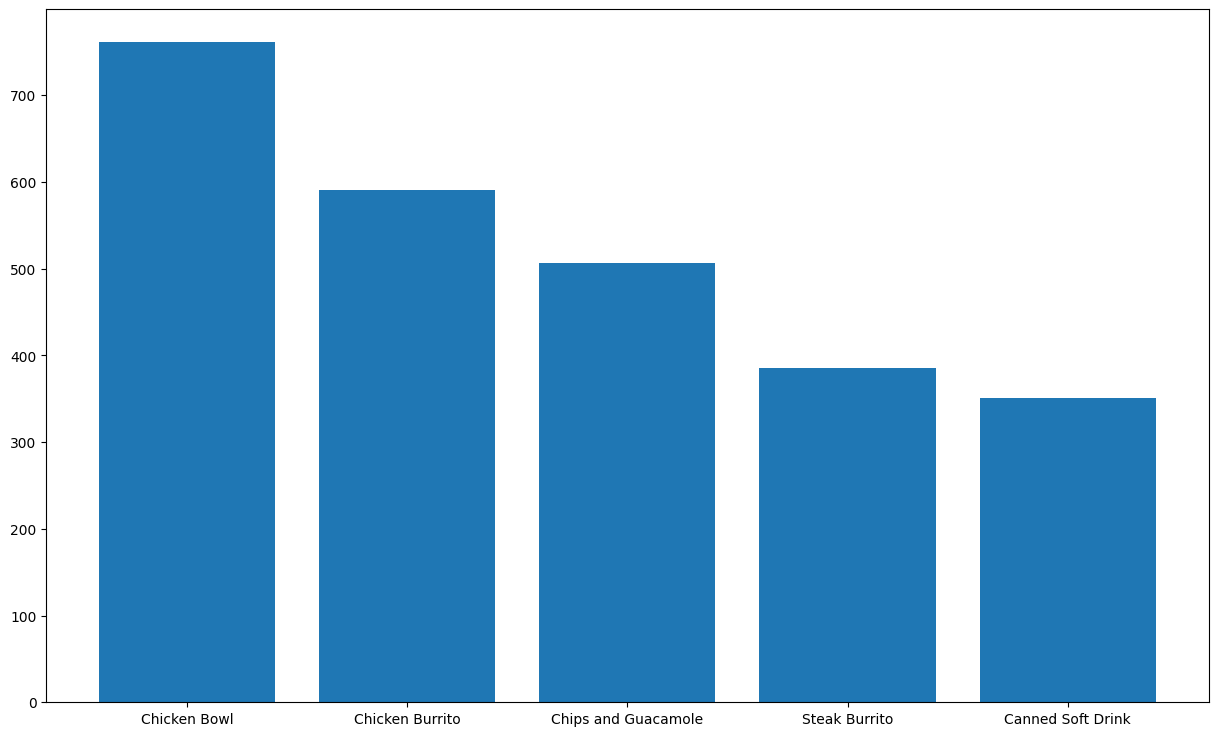

In [ ]:
top_items = chipo.groupby('item_name').sum()
top_items = top_items.sort_values(['quantity'], ascending=False)

plt.figure(figsize=(15,9))
plt.bar(top_items.index[:5], top_items['quantity'][:5])

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

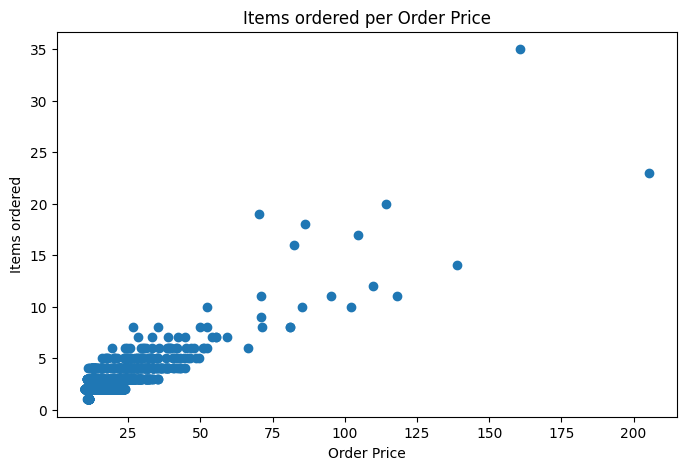

In [ ]:
import matplotlib.pyplot as plt

# price 숫자로 변환
chipo['item_price'] = chipo['item_price'].astype(str).str.replace('$', '').astype(float)
#item price가 숫자여서 str로 바꿔준 후에 str.replace를 해야하는 것
# order별 요약
order_summary = chipo.groupby('order_id').agg({
    'item_price': 'sum',
    'quantity': 'sum'
})

# scatter plot
plt.figure(figsize=(8,5))
plt.scatter(order_summary['item_price'], order_summary['quantity'])

plt.xlabel("Order Price")
plt.ylabel("Items ordered")
plt.title("Items ordered per Order Price")

plt.show()

### Step 7. BONUS: Create a question and a graph to answer your own question.

아이템을 많이 주문하는 고객일수록 더 많은 돈을 쓰는가?

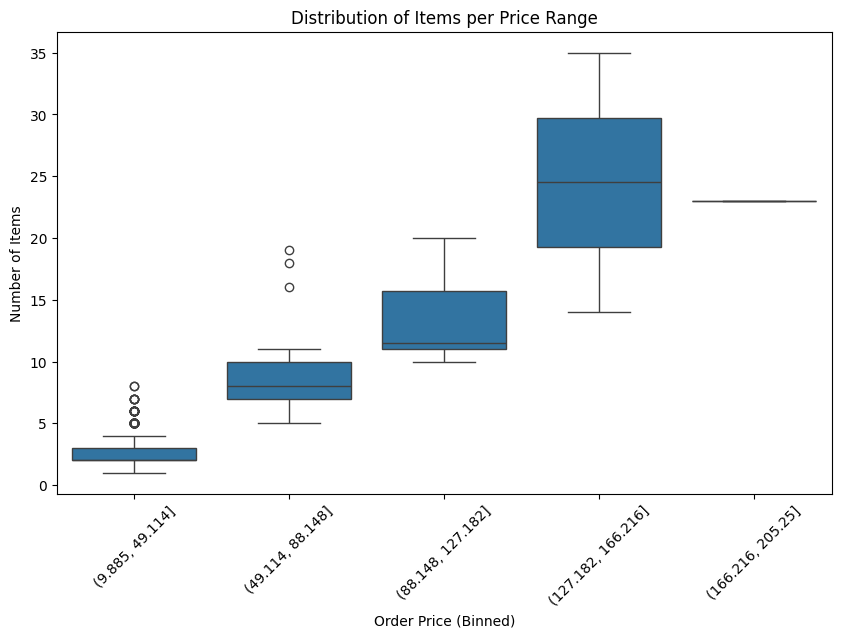

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# item_price 숫자로 변환
if chipo['item_price'].dtype == 'object':
    chipo['item_price'] = chipo['item_price'].str.replace('$', '').astype(float)

# order별 집계
order_summary = chipo.groupby('order_id').agg({
    'item_price': 'sum',
    'quantity': 'sum'
}).reset_index()

# 가격 구간 나누기 (예: 5개 구간)
order_summary['price_bin'] = pd.cut(order_summary['item_price'], bins=5)

# 박스플롯
plt.figure(figsize=(10,6))
sns.boxplot(x='price_bin', y='quantity', data=order_summary)

plt.xlabel("Order Price (Binned)")
plt.ylabel("Number of Items")
plt.title("Distribution of Items per Price Range")

plt.xticks(rotation=45)
plt.show()